In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("ocup.csv")

In [3]:
df

,anos,tasa_ocup,tip_cam
0,2007,"75,60 €","10,90"
1,2008,"75,32 €","10,92"
2,2009,"74,35 €","11,14"
3,2010,"70,98 €","13,49"


In [4]:
print("Base de datos con n=4")
print(df)

Base de datos con n=4
   anos tasa_ocup tip_cam
0  2007   75,60 €   10,90
1  2008   75,32 €   10,92
2  2009   74,35 €   11,14
3  2010   70,98 €   13,49


In [5]:
df['tip_cam'] = (
    df['tip_cam']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)
print(df.dtypes)
print(df)

anos           int64
tasa_ocup        str
tip_cam      float64
dtype: object
   anos tasa_ocup  tip_cam
0  2007   75,60 €    10.90
1  2008   75,32 €    10.92
2  2009   74,35 €    11.14
3  2010   70,98 €    13.49


In [6]:
df['tasa_ocup'] = (
    df['tasa_ocup']
    .str.replace(',', '.', regex=False)
    .str.replace('€', ' ', regex=False)
    .str.strip()
    .astype(float)
)

print(df.dtypes)
print(df)

anos           int64
tasa_ocup    float64
tip_cam      float64
dtype: object
   anos  tasa_ocup  tip_cam
0  2007      75.60    10.90
1  2008      75.32    10.92
2  2009      74.35    11.14
3  2010      70.98    13.49


In [ ]:
from sklearn.linear_model import LinearRegression
#Regresión Lineal simple MCO, x= tipo de cambio, y= tasa de ocupación.
X= df[['tip_cam']]
y= df['tasa_ocup']

modelo = LinearRegression()
modelo.fit(X, y)

b0= modelo.intercept_
b1= modelo.coef_[0]

print(f"\n Intercepto (b0)= {b0:4f}")
print(f"\n Pendiente (b1)= {b1:4f}")
print(f"\n Ecuación (y)= {b0:4f} + {b1:4f}x")


 Intercepto (b0)= 93.409473

 Pendiente (b1)= -1.666047

 Ecuación (y)= 93.409473 + -1.666047x


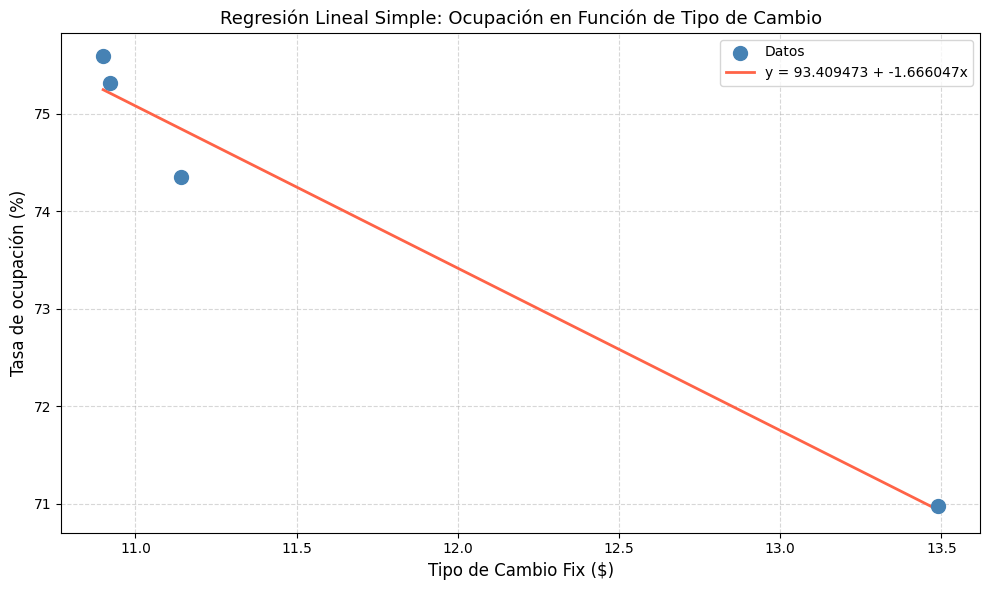

In [13]:
y_pred= modelo.predict(X)
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['tip_cam'], df['tasa_ocup'],
           color='steelblue', s=100, zorder=5, label='Datos')
ax.plot(df['tip_cam'], y_pred,
        color='tomato', linewidth=2, label= f'y = {b0:4f} + {b1:4f}x')

ax.set_xlabel('Tipo de Cambio Fix ($)', fontsize=12)
ax.set_ylabel('Tasa de ocupación (%)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Ocupación en Función de Tipo de Cambio', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
